In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#1. Generate synthetic data

In [2]:
df = pd.read_excel("data.xlsx")

print(df.head())

     elevation      slope    rainfall soil_type  landslide
0  1149.014246  33.577874  120.278617      loam          0
1   958.520710  35.607845  170.031249      clay          1
2  1194.306561  40.830512  200.262185      sand          1
3  1456.908957  40.538021  202.349030      loam          0
4   929.753988  16.223306  177.496726      loam          1


In [3]:
print(df.shape)

(200, 5)


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   elevation  200 non-null    float64
 1   slope      200 non-null    float64
 2   rainfall   200 non-null    float64
 3   soil_type  200 non-null    object 
 4   landslide  200 non-null    int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 7.9+ KB
None


# Simulated features

In [9]:

# Get number of data points from dataset
n_points = len(df)

# Generate variables based on dataset size
solar_irradiance = np.random.normal(loc=5.5, scale=1.0, size=n_points)  # kWh/m2/day
wind_speed = np.random.normal(loc=6.5, scale=1.5, size=n_points)        # m/s
land_slope = np.abs(np.random.normal(loc=5, scale=3, size=n_points))    # degrees
distance_to_road = np.random.uniform(0, 50, size=n_points)              # km
land_use_type = np.random.choice(['barren', 'agricultural', 'urban', 'forest'], size=n_points)

# Normalize/Clip to simulate realistic values

In [10]:
solar_irradiance = np.clip(solar_irradiance, 2, 8)
wind_speed = np.clip(wind_speed, 2, 12)
land_slope = np.clip(land_slope, 0, 30)

# 2. Define weights for suitability criteria

# Higher irradiance, wind speed => more suitable
# Lower slope, distance, urban areas => more suitable

In [11]:
def calculate_suitability(row):
    score = (
        0.3 * (row['solar_irradiance'] / 8) +
        0.3 * (row['wind_speed'] / 12) +
        0.2 * (1 - row['land_slope'] / 30) +
        0.1 * (1 - row['distance_to_road'] / 50)
    )

 # Penalize land use: barren > agricultural > urban > forest

In [13]:
def calculate_suitability(row):
    score = (
        0.3 * (row['solar_irradiance'] / 8) +
        0.3 * (row['wind_speed'] / 12) +
        0.2 * (1 - row['land_slope'] / 30) +
        0.1 * (1 - row['distance_to_road'] / 50)
    )

    land_use_penalty = {
        'barren': 1.0,
        'agricultural': 0.9,
        'urban': 0.7,
        'forest': 0.6
    }

    score *= land_use_penalty[row['land_use_type']]

    return round(score, 2)

# 3. Create DataFrame

In [14]:
df = pd.DataFrame({
    'solar_irradiance': solar_irradiance,
    'wind_speed': wind_speed,
    'land_slope': land_slope,
    'distance_to_road': distance_to_road,
    'land_use_type': land_use_type
})


# 4. Apply suitability scoring

In [15]:
df['suitability_score'] = df.apply(calculate_suitability, axis=1)

# 5. Classify suitability

In [16]:
def classify_suitability(score):
    if score >= 0.7:
        return 'High'
    elif score >= 0.5:
        return 'Moderate'
    else:
        return 'Low'

df['suitability_class'] = df['suitability_score'].apply(classify_suitability)

# 6. Display summary

In [17]:
print(df.head())

   solar_irradiance  wind_speed  land_slope  distance_to_road land_use_type  \
0          5.602937    3.333678    6.101563         27.499900        forest   
1          4.991956    6.976544    0.072651         12.750696         urban   
2          6.120422    8.512700    2.378637         13.782875        forest   
3          4.496844    6.039742    2.934948         22.861684        forest   
4          3.972694    4.423430    5.891568         47.724044        forest   

   suitability_score suitability_class  
0               0.30               Low  
1               0.44               Low  
2               0.42               Low  
3               0.33               Low  
4               0.25               Low  


# 7. Plot suitability distribution

C:\Users\USER\AppData\Local\Temp\ipykernel_5836\1598777731.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='suitability_class', palette='viridis')


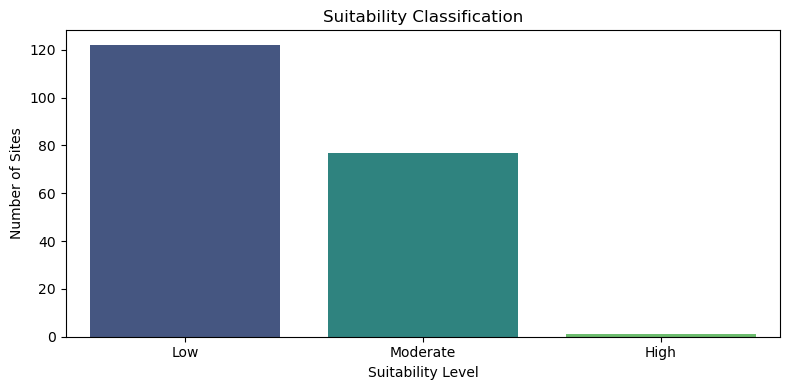

In [18]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='suitability_class', palette='viridis')
plt.title("Suitability Classification")
plt.xlabel("Suitability Level")
plt.ylabel("Number of Sites")
plt.tight_layout()
plt.show()

# visualization

Suitability Classification Distribution

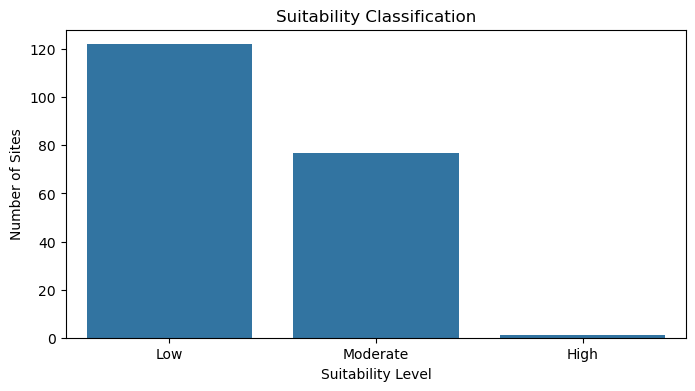

In [19]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='suitability_class')
plt.title("Suitability Classification")
plt.xlabel("Suitability Level")
plt.ylabel("Number of Sites")
plt.show()

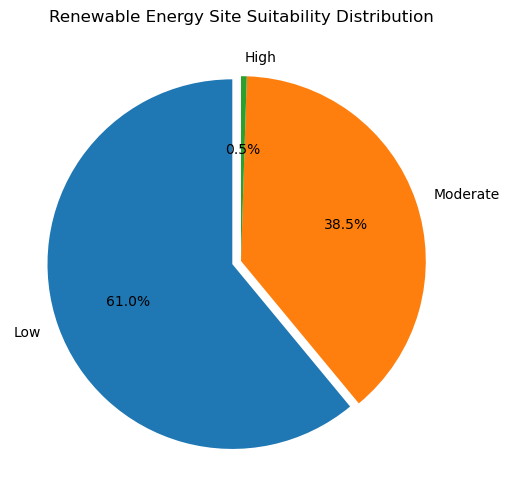

In [21]:
plt.figure(figsize=(6,6))

plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05,0,0)
)

plt.title("Renewable Energy Site Suitability Distribution")

plt.show()

Suitability Score Distribution

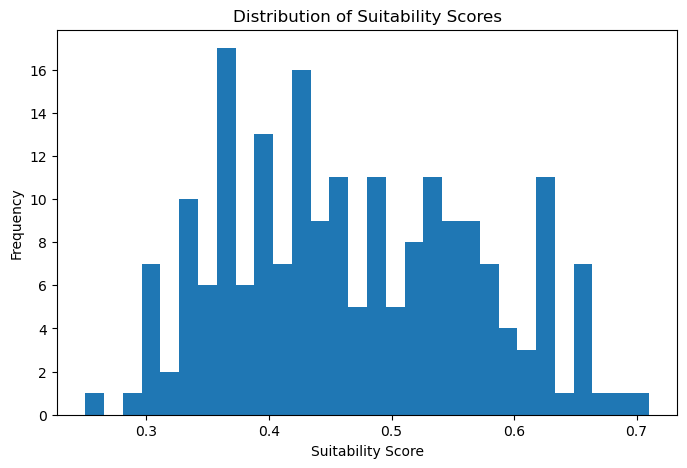

In [22]:
plt.figure(figsize=(8,5))
plt.hist(df['suitability_score'], bins=30)
plt.title("Distribution of Suitability Scores")
plt.xlabel("Suitability Score")
plt.ylabel("Frequency")
plt.show()

Feature Influence on Suitability Score

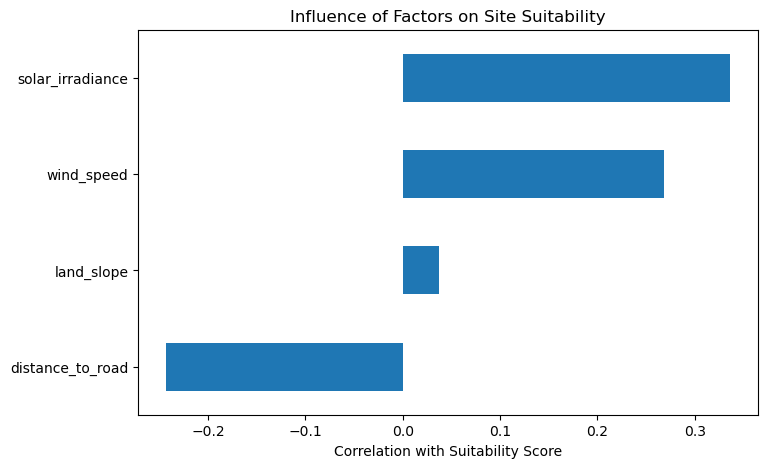

In [23]:
features = ['solar_irradiance','wind_speed','land_slope','distance_to_road']
importance = df[features].corrwith(df['suitability_score'])

importance.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Influence of Factors on Site Suitability")
plt.xlabel("Correlation with Suitability Score")
plt.show()

Relationship Between Renewable Resources

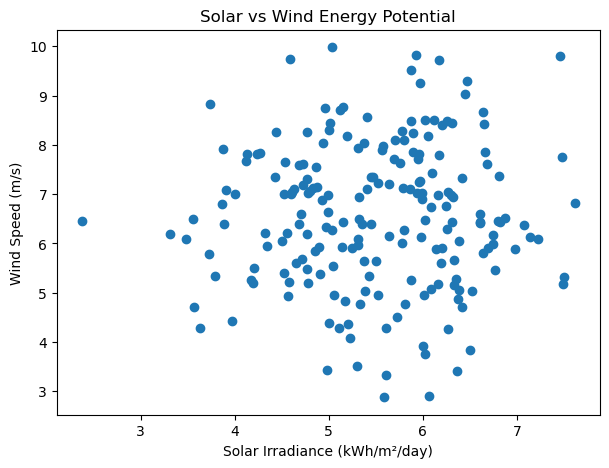

In [24]:
plt.figure(figsize=(7,5))
plt.scatter(df['solar_irradiance'], df['wind_speed'])
plt.xlabel("Solar Irradiance (kWh/m²/day)")
plt.ylabel("Wind Speed (m/s)")
plt.title("Solar vs Wind Energy Potential")
plt.show()

Correlation Heatmap

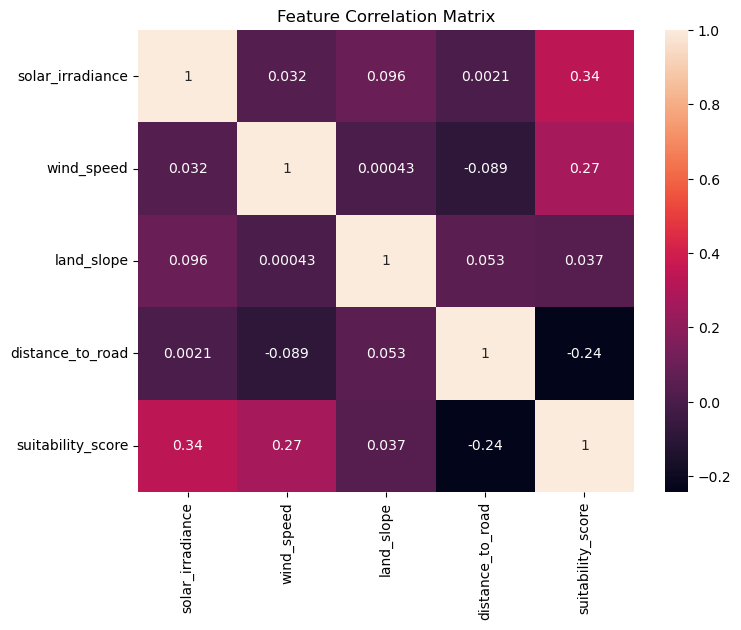

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation Matrix")
plt.show()